# Question 1: Radiative Decay

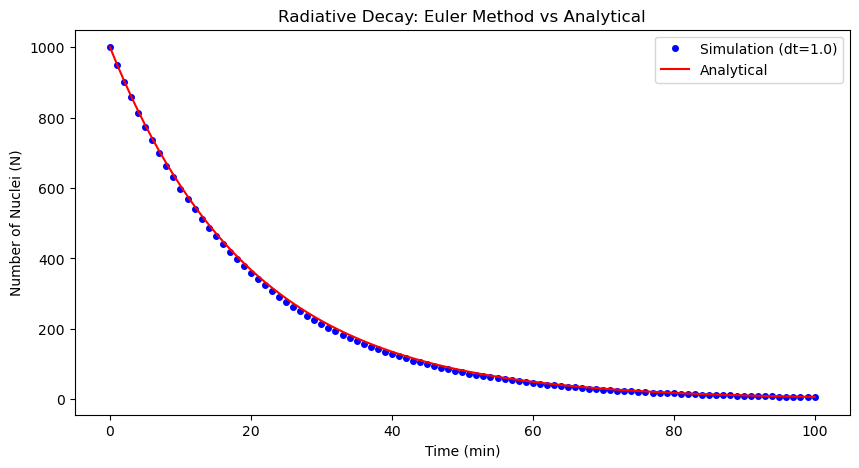

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Basic Simulation 
N0 = 1000       
lam = 0.05       
dt = 1.0         
total_time = 100

t = 0
N = N0
t_list = [t]
N_list = [N]

while t < total_time:
    dN = -lam * N * dt  # calculating the change 
    N = N + dN          
    t = t + dt           
    t_list.append(t)
    N_list.append(N)

# Analytical Solution 
t_analytical = np.linspace(0, total_time, 200)
N_analytical = N0 * np.exp(-lam * t_analytical)

plt.figure(figsize=(10, 5))
plt.plot(t_list, N_list, 'bo', label='Simulation (dt=1.0)', markersize=4)
plt.plot(t_analytical, N_analytical, 'r-', label='Analytical')
plt.xlabel('Time (min)')
plt.ylabel('Number of Nuclei (N)')
plt.title('Euler Method vs Analytical')
plt.legend()
plt.show()

# Task 2 Response: The simulation under-estimates the decay. Because it uses the slope from the start of the step, it doesn't "drop" as fast as the real curve.

# Task 3 Response: A smaller dt makes the simulation much more accurate. t would take too long to run (too many steps), and the computer might run into "round-off" errors where it can't handle such tiny numbers precisely.

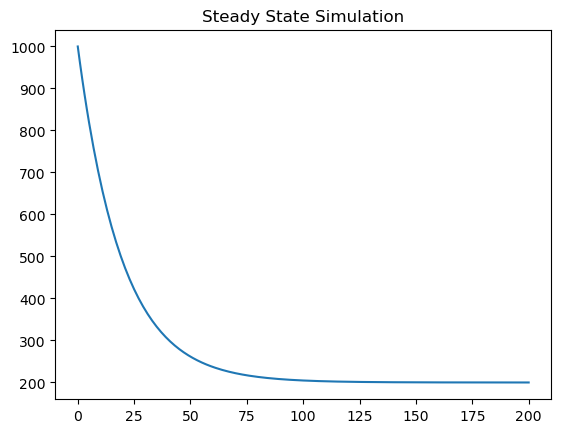

In [3]:
P = 10  # Production Rate
N, t = 1000, 0
t_s, N_s = [t], [N]

while t < 200:
    dN = (P - lam * N) * dt 
    N += dN
    t += dt
    t_s.append(t)
    N_s.append(N)

plt.plot(t_s, N_s)
plt.title("Steady State Simulation")
plt.show()

# Task 4 Response: Yes, it reaches a steady state. The graph levels off at 200 nuclei.

# Question 2: Projectile Motion

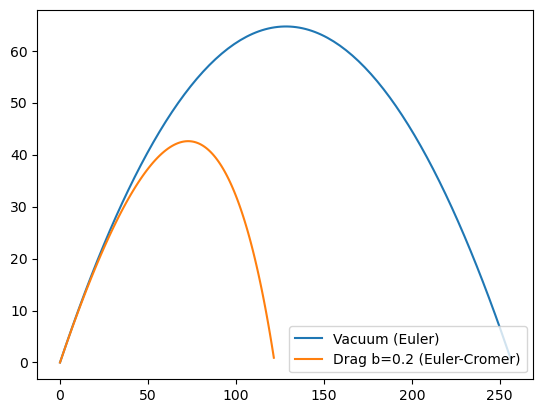

In [4]:
import math

g = 9.8
v0 = 50
theta_deg = 45
theta_rad = math.radians(theta_deg)
dt = 0.05

# Vacuum vs Drag
def simulate_projectile(b, method='euler'):
    vx = v0 * math.cos(theta_rad)
    vy = v0 * math.sin(theta_rad)
    x, y = 0, 0
    xs, ys = [0], [0]
    
    while y >= 0:
        # Acceleration with Linear Drag 
        ax = -(b/1.0) * vx # assuming m=1 for simplicity
        ay = -g - (b/1.0) * vy
        
        if method == 'euler':
            x += vx * dt
            y += vy * dt
            vx += ax * dt
            vy += ay * dt
        elif method == 'euler-cromer': 
            vx += ax * dt
            vy += ay * dt
            x += vx * dt # new velocity
            y += vy * dt
            
        if y >= 0:
            xs.append(x)
            ys.append(y)
    return xs, ys

# Comparison
vac_x, vac_y = simulate_projectile(0, 'euler')
drag_x, drag_y = simulate_projectile(0.2, 'euler-cromer')

plt.plot(vac_x, vac_y, label='Vacuum (Euler)')
plt.plot(drag_x, drag_y, label='Drag b=0.2 (Euler-Cromer)')
plt.legend()
plt.show()

# Task 2 Response: The Euler vacuum simulation usually overshoots the theoretical range because it assumes the velocity is constant during the time step. Air resistance makes the arc asymmetric. The projectile falls much more steeply than it rose.

# Question 3: Newton's Law of Cooling

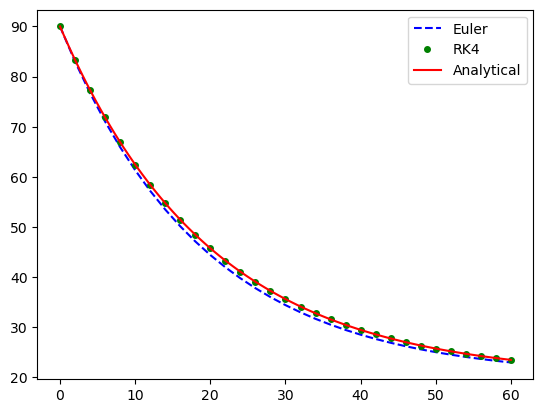

In [5]:
T_env = 20
T0 = 90
K = 0.05
dt = 2.0
total_t = 60

# Euler Method
t_e, T_e = [0], [T0]
T = T0
for _ in np.arange(0, total_t, dt):
    dT = -K * (T - T_env) * dt
    T += dT
    t_e.append(t_e[-1] + dt)
    T_e.append(T)

# RK4 Method 
def f(T): return -K * (T - T_env)

t_rk, T_rk = [0], [T0]
T = T0
for _ in np.arange(0, total_t, dt):
    k1 = f(T)
    k2 = f(T + k1 * dt / 2)
    k3 = f(T + k2 * dt / 2)
    k4 = f(T + k3 * dt)
    T += (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    t_rk.append(t_rk[-1] + dt)
    T_rk.append(T)

# Analytical 
t_ana = np.linspace(0, total_t, 100)
T_ana = T_env + (T0 - T_env) * np.exp(-K * t_ana)

plt.plot(t_e, T_e, 'b--', label='Euler')
plt.plot(t_rk, T_rk, 'go', label='RK4', markersize=4)
plt.plot(t_ana, T_ana, 'r', label='Analytical')
plt.legend()
plt.show()

# Task 3 response: RK4 is much more accurate than Euler when using a large dt. Zooming in on the first 10 minutes, the Euler method is usually off by about 1 to 2 degrees Celsius compared to the exact solution